In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
print(dd.FORT_AVAIL)

True


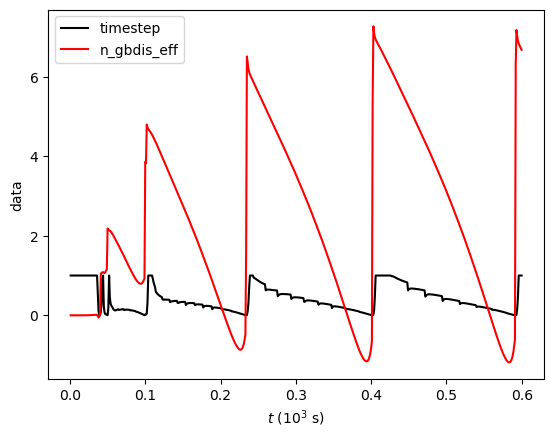

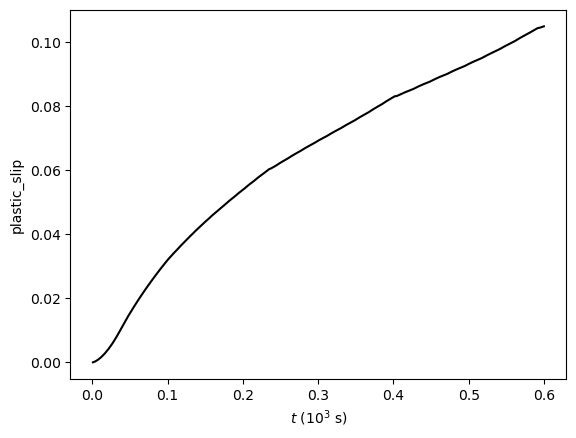

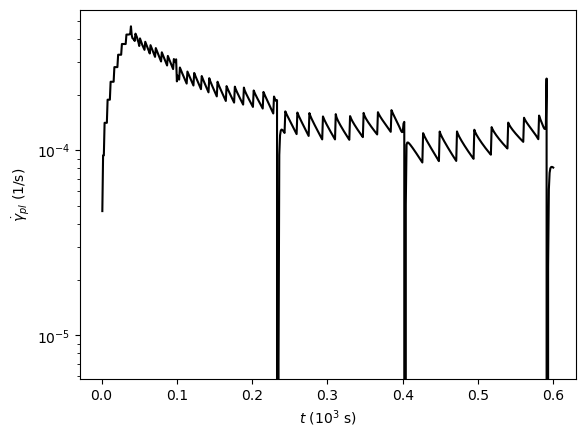

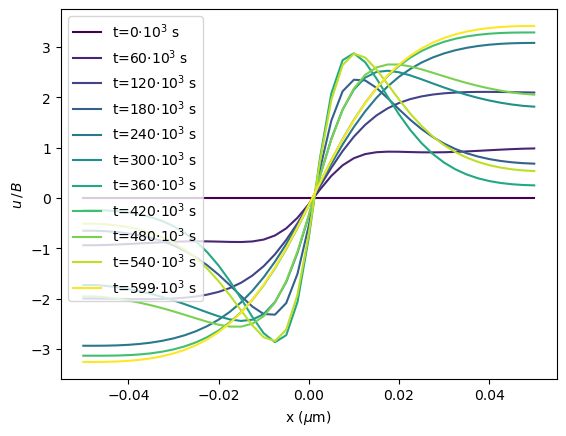

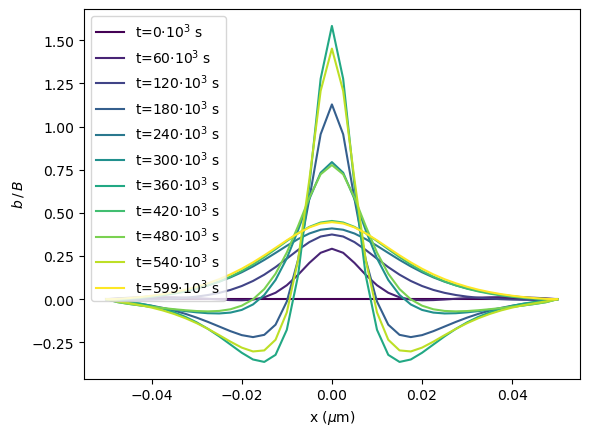

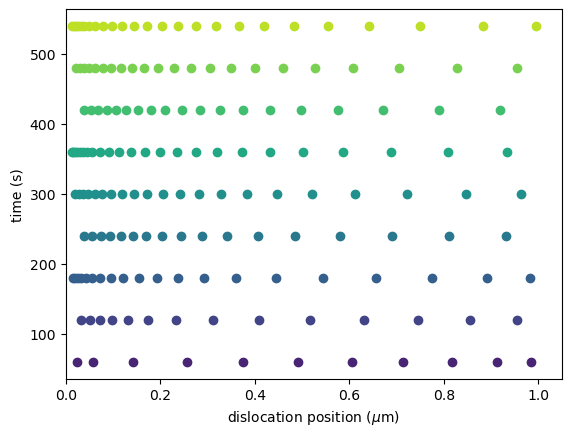

In [2]:
gbdd = dd.GB_dislocations(from_file="../examples/gbdd/pu1_tau150_T900.h5")
gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
gbdd.plot_time_series("plastic_slip")
gbdd.plot_time_series("plast_slip_rate")
gbdd.plot_field('displacement')
gbdd.plot_field('bfield')  # , file="T900_Lgb10_short.pdf")
gbdd.plot_pile_up()
                          

In [29]:
it = 40
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
ngbn = gbdd.Ngbn
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
gbf = gbdd.pu_dis['force'][it, ind]

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
#dsl.plot_stress(show_arrows=False)
fpk = dsl.calc_force(tau0=-gbdd.tau0)
print(by)
print(yp[:npu])
print(fpk[1, :])
print(gbf)
print(f"Rel. error in leading dislocation: {fpk[1, 0]/gbf[0]-1}")
print(f"Average rel. error in pile-up: {np.sum(np.abs(fpk[1, :npu]/gbf[:npu]-1))/npu}")

[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  0.00000000e+00  1.95913253e-03
  2.09922232e-03  1.64390953e-03  1.04892986e-03  6.32788189e-04
  6.70938498e-04  1.41189501e-03  3.06204259e-03  5.73957818e-03
  9.37613259e-03  1.35128093e-02  1.68774478e-02  1.65268979e-02
  6.23178326e-03 -2.59244766e-02 -9.78198292e-02 -2.13463176e-01
 -2.59780534e-01  1.56649541e-01  7.43565889e-01  1.56649541e-01
 -2.59780534e-01 -2.13463176e-01 -9.78198292e-02 -2.59244766e-02
  6.23178326e-03  1.65268979e-02  1.68774478e-02  1.35128093e-02
  9.37613259e-03  5.73957818e-03  3.06204259e-03  1.41189501e-03
  6.70938498e-04  6.32788189e-04  1.04892986e-03  1.64390953e-03
  2.09922232e-03  1.95913253e-03  0.00000000e+00]
[0.0068181  0.14997587 0.28452949 0.40763479 0.52333285 0.63319467
 0.73750826 0.83540855 0.92402465 0.98802283]
[ 0.03065775 -0.04661955 -0.04442309 -0.04221918 -0.04008

In [ ]:
yp


In [ ]:
N = 100
res = []
for i in range(N):
    xp = np.random.rand(2)*5
    yp = np.random.rand(2)*5
    sp = np.random.rand(1)[0]*np.pi*.5
    df = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=5, LY=5,
                          bc="fixed")
    dp = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=50000, LY=50000,
                          bc="pbc")
    res.append(df.calc_force(tau0=0) / dp.calc_force(tau0=0) - 1)
    #print(dp.xpos, dp.ypos)
    #print(dp.bx, dp.by)
    #print(res[i])
print(np.max(np.abs(res)))


In [ ]:
mu = 80.0e3          # shear modulus
nu = 0.3             # Poisson ratio
b0 = 0.2e-3          # Burgers vector norm
C = mu*b0/(2*np.pi*(1.-nu))   # Constant for dislocation stress field
f0 = 10.             # initial slip resistance

#define box 
LX = LY = 10.

#define different dislocations in box
dsl10 = dd.Dislocations(1, 0, 0., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl10.plot_stress()             # plot elastic fields

dsl01 = dd.Dislocations(1, 0, 90.*np.pi/180., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl01.plot_stress()             # plot elastic fields

dsl11 = dd.Dislocations(1, 0, 45.*np.pi/180., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl11.plot_stress()             # plot elastic fields